# Extension 1 - Residual confounding sensitivity benchmark

This notebook takes the frozen survey-weighted, covariate-standardized NFHS-5 private/public risk ratio as input. It asks what **hypothetical residual confounding strengths, conditional on the measured adjustment variables**, would be sufficient to move a causal interpretation of that association toward the null. It does **not** claim a causal facility-switch effect, identify a missing factor, or estimate corrected risks or risk differences.

Earlier versions mixed the observed sector-specific later-delivery shares into a bias factor even though birth order is an adjustment variable. That calculation has been removed. No fabricated prior-Cesarean or severity-composite prevalence is used here.

## 1. Load the frozen primary estimate

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path.cwd().resolve()
assert notebook_dir.name == "01_quantitative_bias", "Open this notebook from its own extension folder."
sys.path.insert(0, str((notebook_dir.parent / "shared").resolve()))
import config

out = notebook_dir / "outputs"
out.mkdir(exist_ok=True)
table_path = config.V2_FINAL_TABLES_DIR / "final_aipw_overall_table.csv"
assert table_path.is_file(), f"Frozen primary table not found: {table_path}"
primary_table = pd.read_csv(table_path)
assert len(primary_table) >= 1
primary = primary_table.iloc[0]
rr_ref = float(primary["risk_ratio"])
rr_ci_low = float(primary["risk_ratio_ci_low"])
rd_ref = float(primary["risk_difference_pct"])
r_private = float(primary["r1_hat_private_risk_pct"])
r_public = float(primary["r0_hat_public_risk_pct"])
n_analytic = int(primary["n_analytic"])
assert rr_ref > 1 and 1 < rr_ci_low <= rr_ref
assert np.isclose(r_private / r_public, rr_ref, rtol=1e-6)
assert np.isclose(r_private - r_public, rd_ref, atol=1e-6)
print(f"Frozen reference: n={n_analytic:,}, private={r_private:.4f}%, public={r_public:.4f}%")
print(f"RD={rd_ref:.4f} percentage points; RR={rr_ref:.4f} (95% CI lower limit {rr_ci_low:.4f})")

Frozen reference: n=200,794, private=44.9644%, public=16.4946%
RD=28.4698 percentage points; RR=2.7260 (95% CI lower limit 2.6566)


## 2. Bound on residual confounding

Let `RR_AU` be the maximum association between sector and an unmeasured factor (or factors), and `RR_UY` the maximum association between that factor and Cesarean outcome, **within measured-covariate strata**. Both are sensitivity parameters, not observed estimates. Their joint bounding factor is `B = RR_AU * RR_UY / (RR_AU + RR_UY - 1)`. Values start at one (no association). The grid reports `RR_observed / B` as a **sensitivity lower bound under a hypothetical causal interpretation**, not an estimated corrected RR. A cell reaching one only says those assumed strengths could be large enough to explain away the point estimate; it does not show that such a factor exists.

Source: Ding and VanderWeele, *Epidemiology* 2016, DOI 10.1097/EDE.0000000000000457; VanderWeele and Ding, *Annals of Internal Medicine* 2017, DOI 10.7326/M16-2607. Applicability of a causal estimand for the broad sector comparison remains under discussion.

In [2]:
def bounding_factor(rr_au, rr_uy):
    rr_au = np.asarray(rr_au, dtype=float)
    rr_uy = np.asarray(rr_uy, dtype=float)
    if np.any(rr_au < 1) or np.any(rr_uy < 1):
        raise ValueError("Sensitivity strengths must be at least one.")
    return rr_au * rr_uy / (rr_au + rr_uy - 1)

def e_value(rr):
    if rr < 1:
        raise ValueError("This notebook expects a risk ratio above one.")
    return rr + np.sqrt(rr * (rr - 1))

e_point = e_value(rr_ref)
e_ci = e_value(rr_ci_low)
assert np.isclose(bounding_factor(1, 1), 1)
assert np.isclose(bounding_factor(e_point, e_point), rr_ref)
assert np.isclose(bounding_factor(e_ci, e_ci), rr_ci_low)
print(f"E-value for point estimate: {e_point:.3f}")
print(f"E-value for confidence-limit nearest null: {e_ci:.3f}")

E-value for point estimate: 4.895
E-value for confidence-limit nearest null: 4.754


## 3. Hypothetical strength grid

The 1-to-8 range is an arbitrary display range; **no clinical or literature calibration is claimed**. It is a deterministic sensitivity surface, not a probability distribution or confidence interval.

In [3]:
strengths = np.round(np.arange(1.0, 8.0001, 0.25), 2)
grid_rows = []
for rr_au in strengths:
    for rr_uy in strengths:
        bf = float(bounding_factor(rr_au, rr_uy))
        grid_rows.append({
            "rr_au_conditional": rr_au,
            "rr_uy_conditional": rr_uy,
            "bounding_factor": bf,
            "rr_reference": rr_ref,
            "rr_lower_bound_hypothetical": rr_ref / bf,
            "strengths_sufficient_for_null_bound": bool(bf >= rr_ref),
            "parameter_status": "hypothetical / unsourced",
        })
grid = pd.DataFrame(grid_rows)
grid_path = out / "qba_scenario_results.csv"
grid.to_csv(grid_path, index=False)
assert len(grid) == len(strengths)**2
assert np.isclose(grid.query("rr_au_conditional == 1 and rr_uy_conditional == 1").iloc[0]["rr_lower_bound_hypothetical"], rr_ref)
print(f"Saved {grid_path} ({len(grid):,} hypothetical pairs)")

Saved C:\Users\Tushna\IPD\extensions_work\01_quantitative_bias\outputs\qba_scenario_results.csv (841 hypothetical pairs)


## 4. Summary and figure

,rr_au_conditional,rr_uy_conditional,bounding_factor,rr_lower_bound_hypothetical,strengths_sufficient_for_null_bound,parameter_status
0,1,1,1.000000,2.726007,False,hypothetical / unsourced
1,2,2,1.333333,2.044505,False,hypothetical / unsourced
2,3,3,1.800000,1.514448,False,hypothetical / unsourced
3,4,4,2.285714,1.192628,False,hypothetical / unsourced
4,5,5,2.777778,0.981363,True,hypothetical / unsourced
5,6,6,3.272727,0.832947,True,hypothetical / unsourced
6,8,8,4.266667,0.638908,True,hypothetical / unsourced


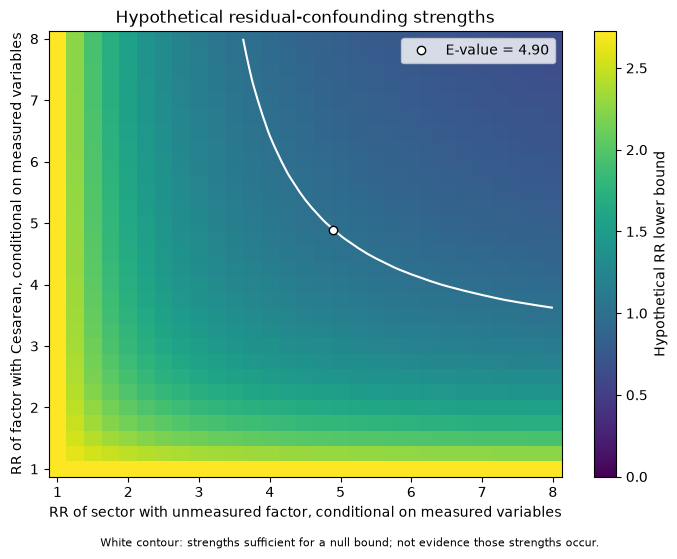

In [4]:
pairs = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (8, 8)]
summary = pd.DataFrame([{
    "rr_au_conditional": a, "rr_uy_conditional": y,
    "bounding_factor": float(bounding_factor(a, y)),
    "rr_lower_bound_hypothetical": rr_ref / float(bounding_factor(a, y)),
    "strengths_sufficient_for_null_bound": bool(bounding_factor(a, y) >= rr_ref),
    "parameter_status": "hypothetical / unsourced",
} for a, y in pairs])
summary.to_csv(out / "qba_summary.csv", index=False)
display(summary)

x, y = np.meshgrid(strengths, strengths)
z = rr_ref / bounding_factor(x, y)
fig, ax = plt.subplots(figsize=(7.1, 5.6))
img = ax.pcolormesh(x, y, z, shading="auto", cmap="viridis", vmin=0, vmax=rr_ref)
fig.colorbar(img, ax=ax, label="Hypothetical RR lower bound")
ax.contour(x, y, z, levels=[1], colors="white", linewidths=1.5)
ax.plot(e_point, e_point, "wo", markeredgecolor="black", label=f"E-value = {e_point:.2f}")
ax.set(xlabel="RR of sector with unmeasured factor, conditional on measured variables",
       ylabel="RR of factor with Cesarean, conditional on measured variables",
       title="Hypothetical residual-confounding strengths")
ax.legend(loc="upper right", frameon=True)
fig.text(0.5, 0.015, "White contour: strengths sufficient for a null bound; not evidence those strengths occur.", ha="center", fontsize=8)
fig.tight_layout(rect=[0, .035, 1, 1])
fig.savefig(out / "qba_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Sources, audit and scope

In [5]:
sources = pd.DataFrame([
    {"item":"Frozen NFHS-5 standardized AIPW sector association", "value":f"RR {rr_ref:.6f}; RD {rd_ref:.6f} pp", "status":"project result", "source":str(table_path), "use":"reference only; no refitting"},
    {"item":"Bounding factor and E-value method", "value":"RR_AU*RR_UY/(RR_AU+RR_UY-1)", "status":"published method", "source":"Ding & VanderWeele 2016, doi:10.1097/EDE.0000000000000457; VanderWeele & Ding 2017, doi:10.7326/M16-2607", "use":"conditional-on-measured-covariates sensitivity benchmark"},
    {"item":"RR_AU and RR_UY grid", "value":"1 to 8 in steps of 0.25", "status":"hypothetical / unsourced", "source":"none", "use":"illustration only; not calibrated to prior Cesarean or obstetric severity"},
])
sources.to_csv(out / "assumptions_sources.csv", index=False)
metadata = {
    "analysis": "conditional residual-confounding bounding-factor benchmark",
    "n_analytic": n_analytic,
    "reference_risk_ratio": rr_ref,
    "reference_risk_ratio_ci_low": rr_ci_low,
    "reference_risk_difference_pp": rd_ref,
    "e_value_point": float(e_point),
    "e_value_ci_limit": float(e_ci),
    "grid_rows": int(len(grid)),
    "caveat": "No causal sector intervention is established; strengths unsourced; no corrected RR/RD or probability of residual confounding is estimated.",
}
(out / "qba_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")
print("Saved sources and metadata. Outputs use the frozen reference table only.")

Saved sources and metadata. Outputs use the frozen reference table only.


## Interpretation and remaining decisions

- The E-values are **strength benchmarks conditional on the measured variables**, not evidence that residual confounding is absent or that the sector association is causal.
- The heatmap uses unsourced hypothetical strengths. It cannot be labeled as prior-Cesarean-specific or severity-specific evidence.
- The reported original risk difference is unchanged. No sensitivity-adjusted risk difference, Monte Carlo confidence statement, or clinically calibrated conclusion is produced.
- Before manuscript inclusion, ask the supervisor whether a causal interpretation is sufficiently defined to warrant an E-value, and obtain verified, relevant strength estimates if naming a particular unmeasured factor. Otherwise report this as a limited methods illustration or omit it.